In [2]:
import pandas as pd

In [3]:
# Here parse_dates is given as Month so pandas convert it into date time values, it considered the date as 01(first day of each month)
stk_data=pd.read_csv("airline-passengers.csv",
                     parse_dates=["Month"],
                    index_col="Month")

In [4]:
stk_data

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


Text(0, 0.5, 'no of passengers')

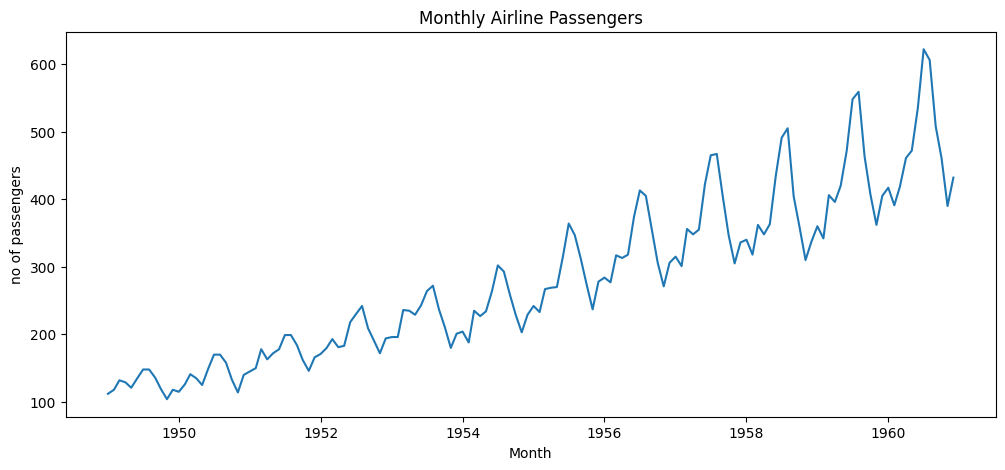

In [5]:
# Visualization the time series
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(stk_data.index,stk_data["Passengers"])
plt.title("Monthly Airline Passengers")
plt.xlabel("Month")
plt.ylabel("no of passengers")

## Question 2 : Check for Missing Values and Summary Stats
### Display missing values and basic statistics for the “AirPassengers” dataset


In [6]:
from Descriptive import Descriptive

In [7]:
obj=Descriptive()

In [8]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [9]:
dataset=stk_data
quan,qual=obj.segreQuanQual(dataset)

The Quantitative Data: ['Passengers']
The Qualtitative Data []


In [10]:
des_data=obj.descriptive_Analysis(dataset,quan)

D:\AI DS Course\Week 13 - Time series Analysis\1.Time_Series_Analysis_Quesion_Set1\4.Coding\Descriptive.py:24: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  des_data[i]["Null_count"]=dataset[i].isnull().sum()
D:\AI DS Course\Week 13 - Time s

In [11]:
des_data

,Passengers
Null_count,0
NonNull_count,144
Total_Count,144
Mean,280.298611
Median,265.5
Mode,229
Std,119.966317
Min,104.0
Q1:25%,180.0
Q2:50%,265.5


### Question 3 : Decompose the Time Series
## Decompose the time series into trend, seasonality, and residuals for the “AirPassengers” dataset.


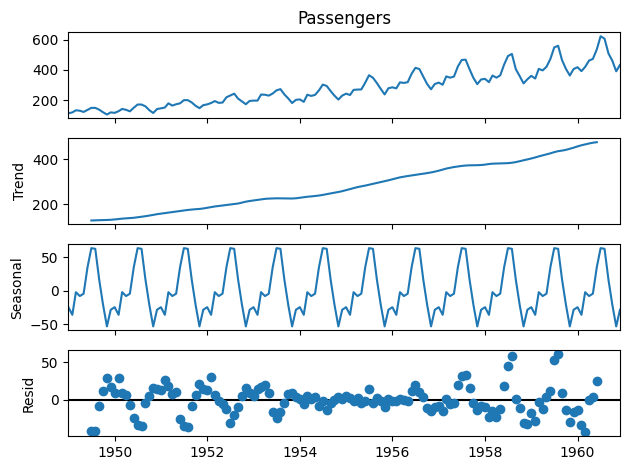

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

#decompose the time series
result=seasonal_decompose(
    stk_data["Passengers"],
    model="additive",
    period=12
)

result.plot()
plt.show()

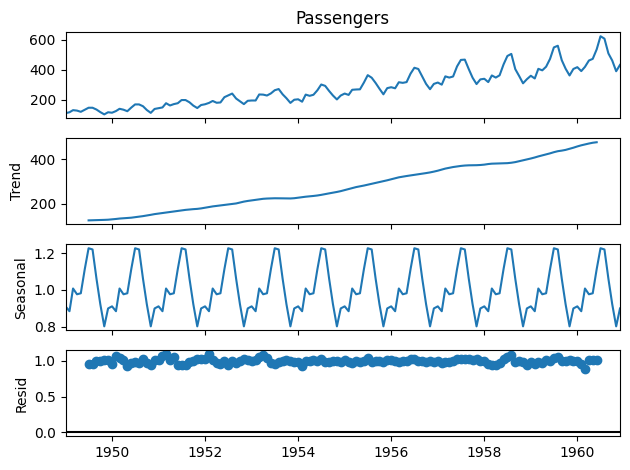

In [13]:
result1 = seasonal_decompose(
    stk_data["Passengers"],
    model="multiplicative",
    period=12
)
result1.plot()
plt.show()

## Question 4 : Check Stationarity with Augmented Dickey-Fuller Test
### Check if the time series is stationary for the above dataset.

In [26]:
# to check whether the time series is station or not using Augmented Dickey_fullertest
from statsmodels.tsa.stattools import adfuller
# function to determine the stationarity
# passing timeseries, dataframe and pollutant for OHLC input
def adf_test(timeseries,df,pollutant):
    plt.figure(figsize=(16,5))
    from statsmodels.tsa.stattools import adfuller
    # Heading to print the resulst
    print("Results of the Dickey-Fuller test")
    # To run the augmented dickey-Fuller test, we pass the timeseries(dataset) and autolag value as "AIC" to the adfuller method
    dftest=adfuller(timeseries,autolag="AIC")
    # The result of this test is a tuple contain 5 values, so it is converted into series and stored in dfoutput 
    dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    #mapping percentage(1,5,10) of critical value for each value in the dfoutput with their respective key
    # so each column for each percentage is created here
    for key, value in dftest[4].items():
        dfoutput['Critical Value(%s)' %key]=value
    print(dfoutput)
    #stores the test output to another variable "ans"
    ans=dfoutput
    print("Condition")
    print("p-value<=0.05--> Accept alternate hypothesis")
    print("p-value>=0.05--> Accept null hypothesis")
    #condition to accept alternate hypothesis is given in the if clause
    if(ans["Test Statistic"]<ans["Critical Value(1%)"] or ans["Test Statistic"]<ans["Critical Value(5%)"] or ans["Test Statistic"]<ans["Critical Value(10%)"] and ans["p-value"]<=0.05):
        print("Condition:statistic<any Critical Value and p-value<0.05 to reject null hypothesis")
        print("Reject Null hypothesis:Stationarity")
        print("Accept Alternate hypothesis: Stationarity")
        message="Stationarity based on ADH"
    else:
        print("Condition:statistic>all critical value and p-value > 0.05 to accept null hypothesis")
        print("Accept Null hypothesis: Non-Stationarity")
        print("Reject Alternate hypothesis: Non-Stationarity")
        message="Non-Stationarity based on ADH"
    plt.plot(df.index,df[pollutant],label=pollutant)
    plt.legend(loc='best')
    plt.title("{}_{}_1949 to 1960".format(message,pollutant))
    plt.savefig("{}_ADH.png".format(pollutant))
    plt.show()
    return message
    

Results of the Dickey-Fuller test
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value(1%)              -3.481682
Critical Value(5%)              -2.884042
Critical Value(10%)             -2.578770
dtype: float64
Condition
p-value<=0.05--> Accept alternate hypothesis
p-value>=0.05--> Accept null hypothesis
Condition:statistic>all critical value and p-value > 0.05 to accept null hypothesis
Accept Null hypothesis: Non-Stationarity
Reject Alternate hypothesis: Non-Stationarity


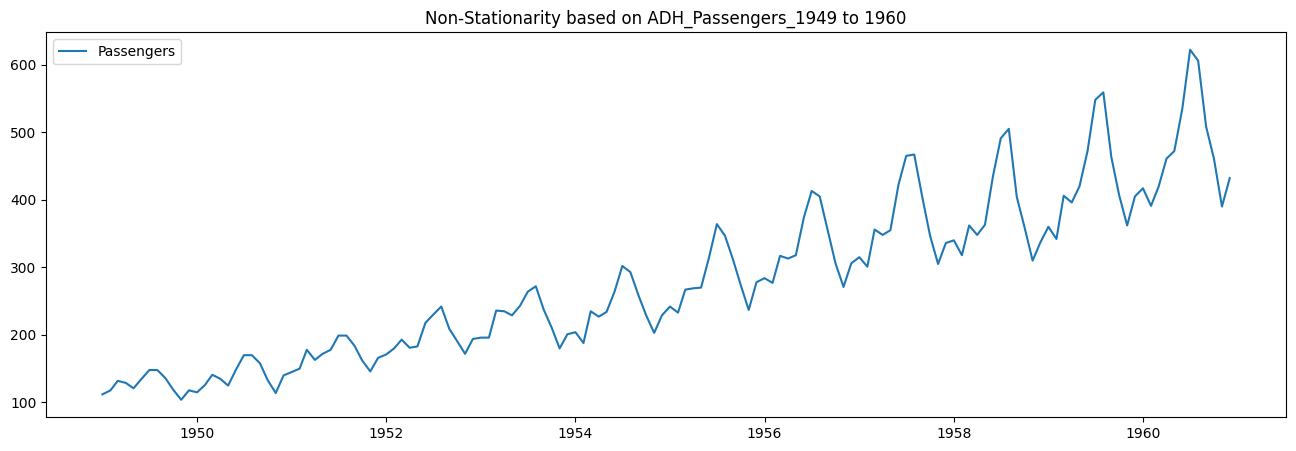

'Non-Stationarity based on ADH'

In [27]:
adf_test(stk_data["Passengers"],stk_data,"Passengers")

In [28]:
from sklearn.preprocessing import MinMaxScaler
Ms=MinMaxScaler()
data1=Ms.fit_transform(stk_data[["Passengers"]])
print("Len:",data1.shape)

Len: (144, 1)


In [30]:
# Train and Test data split
# 80% data is assigned for training
training_size=round(len(data1)*0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
Y_train=data1[:training_size]
Y_test=data1[training_size:]
print("Y_train length:",Y_train.shape)
print("Y_test length:",Y_test.shape)

115
X_train length: (115, 1)
X_test length: (29, 1)
Y_train length: (115, 1)
Y_test length: (29, 1)
